# Chapter 06: Spectral Theory

**Source span read:** physical PDF pages 55-64 of *Mathematical Foundations of Geometric Deep Learning*. The source span introduces eigenfunctions and eigenvalues, the spectral theorem for self-adjoint operators, the periodic Laplacian, singular values, Fourier coefficients, Parseval's identity, the heat equation, and the spectral bridge to geometric deep learning.

**Chapter goal:** build a computational mental model for spectral coordinates: a direction, function, or graph signal becomes easier to understand when an operator acts diagonally on the right basis.

This notebook is standalone. It uses the source span only for orientation and terminology; the prose, code, diagrams, and checks below are original. The main question is concrete: when can an operator be replaced by scalar multipliers on modes, and what geometry is preserved by that replacement?

## Translation guide: computational dictionary

| Source idea | Computational object in this notebook | What to inspect |
| --- | --- | --- |
| Eigenvector or eigenfunction | A vector or sampled function satisfying `A @ v = lambda * v` | The residual `A @ v - lambda * v` and the unchanged line or shape of the mode |
| Self-adjoint operator | Symmetric or Hermitian matrix, plus the periodic Laplacian | Real eigenvalues, orthogonal eigenvectors, and a diagonal Gram matrix |
| Fourier basis | Complex exponentials sampled on a periodic grid | The Gram matrix approximating the Kronecker delta |
| SVD | `A = U @ Sigma @ V.T` for a non-self-adjoint matrix | Domain directions `v_i` mapped to codomain directions `sigma_i u_i` |
| Parseval identity | A unitary discrete Fourier matrix | Equal energy before and after moving to coefficients |
| Heat flow | Spectral filter `exp(lambda_n t)` applied to Laplacian modes | High-frequency coefficients shrink fastest while the average mode is preserved |
| Graph Laplacian bridge | Cycle-graph Laplacian eigenvectors | The graph version of Fourier modes and smoothness energy |


## Visual storyboard and chapter implementation brief

**Concept inventory.** The chapter moves from finite eigen-directions to Hilbert-space eigenfunctions, then uses self-adjointness to guarantee real orthogonal modes. The periodic Laplacian supplies the working example: complex exponentials are eigenfunctions, their Gram matrix is the Kronecker delta, and Fourier coefficients reconstruct signals. SVD handles operators that are not self-adjoint. Parseval turns coefficient space into an isometric proxy for signal space. Heat flow shows why spectra matter operationally: the Laplacian diagonalizes diffusion. The graph Laplacian is the finite irregular-domain bridge used in geometric deep learning.

**Library routing table.**

| Concept | Representation | Library | Why this route |
| --- | --- | --- | --- |
| Eigen-directions | Static 2D transformation diagram | Matplotlib + NumPy | Equal-aspect arrows make invariant lines and sign flips inspectable |
| Self-adjoint proof moves | Proof dependency graph and eigenvector Gram matrix | NetworkX + SciPy `eigh` | Theorems about real spectra and orthogonality are better seen as dependencies plus residuals |
| Periodic Laplacian modes | Sampled modes and discrete eigenvalue residuals | NumPy + SciPy | The finite grid exposes the continuum idea without hiding the operator |
| Fourier coefficients | Gram heatmap and coefficient ledger | NumPy + Matplotlib + CSV | The Kronecker-delta claim is visible as a matrix and auditable as numbers |
| SVD | Unit circle to ellipse with singular directions | SciPy `svd` + Matplotlib | Non-self-adjoint stretch is geometric rather than only algebraic |
| Heat equation | Mode damping curves and an interactive slider | Plotly + Matplotlib | Time variation is the concept, so an HTML slider is worth the extra artifact |
| Graph Laplacian | Cycle graph colored by eigenmodes | NetworkX + SciPy | The cycle graph is a finite circle where graph Fourier modes can be compared to classical modes |

**Visual sequence and artifact plan.**

1. `figures/eigen-directions-stretch-sign.png`: invariant lines, stretch, compression, and negative-eigenvalue reversal.
2. `figures/self-adjoint-spectrum-orthogonality.png`: proof dependency graph for real spectra and orthogonal modes, with a Hermitian Gram check.
3. `figures/periodic-laplacian-eigenmodes.png`: sampled periodic Laplacian eigenmodes and discrete eigenvalue residuals.
4. `figures/fourier-gram-kronecker-delta.png` plus `tables/fourier-coefficient-ledger.csv`: Fourier Gram matrix, signal coefficients, and reconstruction.
5. `figures/svd-stretch-directions.png`: singular vectors for a non-self-adjoint linear map.
6. `figures/parseval-energy-ledger.png`: equal energy in signal coordinates and Fourier coordinates.
7. `figures/heat-equation-mode-decay.png` and `html/heat-flow-spectral-slider.html`: heat flow as spectral damping.
8. `figures/graph-laplacian-fourier-bridge.png` plus `tables/graph-laplacian-spectrum.csv`: graph Fourier modes on a cycle.
9. `figures/graph-heat-filter-lab.png`: applied graph heat filtering lab.
10. `checks/visual-storyboard.json`, `checks/spectral-invariants.json`, and `checks/final-sanity.json`: reproducible checks.

**Proof-visualization strategy.** The self-adjoint theorems are encoded as a directed dependency graph: the adjoint identity feeds the real-eigenvalue calculation, and the same identity plus distinct eigenvalues feeds orthogonality. The notebook then verifies the theorem numerically on a Hermitian matrix.

**Acceptance checks.** The final cell asserts eigen residuals, self-adjoint orthogonality, Fourier Gram identity, SVD reconstruction, Parseval energy equality, heat-flow monotonicity, graph Laplacian spectrum, artifact existence, and nonblank PNG statistics.


In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.linalg import eigh, svd
import networkx as nx
import plotly.graph_objects as go

# Locate the course root whether the notebook is executed from its folder or from the workspace root.
cwd = Path.cwd().resolve()
search_roots = [cwd, *cwd.parents]
for base in [cwd, *cwd.parents]:
    search_roots.extend(base.glob("Mathematical-Foundations-of-Geometric-Deep-Learning"))

BOOK_ROOT = None
for candidate in search_roots:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate.resolve()
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not find the MFGDL book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_matplotlib, save_plotly_html, save_json, save_table_csv
from utils.notebook_checks import assert_chapter_artifacts, assert_nonblank_image

TOPIC = "chapter-06"
ARTIFACT_LIBRARY_ROOT = BOOK_ROOT / "artifacts"
ARTIFACT_ROOT = ARTIFACT_LIBRARY_ROOT / TOPIC
for kind in ["figures", "html", "tables", "checks"]:
    (ARTIFACT_ROOT / kind).mkdir(parents=True, exist_ok=True)

EXPECTED_RELATIVE = {
    "figures/eigen-directions-stretch-sign.png",
    "figures/self-adjoint-spectrum-orthogonality.png",
    "figures/periodic-laplacian-eigenmodes.png",
    "figures/fourier-gram-kronecker-delta.png",
    "figures/svd-stretch-directions.png",
    "figures/parseval-energy-ledger.png",
    "figures/heat-equation-mode-decay.png",
    "figures/graph-laplacian-fourier-bridge.png",
    "figures/graph-heat-filter-lab.png",
    "html/heat-flow-spectral-slider.html",
    "tables/fourier-coefficient-ledger.csv",
    "tables/graph-laplacian-spectrum.csv",
    "checks/visual-storyboard.json",
    "checks/spectral-invariants.json",
    "checks/final-sanity.json",
}

removed_stale = []
for path in sorted(ARTIFACT_ROOT.rglob("*")):
    if path.is_file():
        relative = path.relative_to(ARTIFACT_ROOT).as_posix()
        if relative not in EXPECTED_RELATIVE:
            removed_stale.append(relative)
            path.unlink()

artifact_paths = []
png_paths = []
checks = {
    "source_span_read": "PDF physical pages 55-64",
    "removed_stale_artifacts": removed_stale,
}


def register(path):
    path = Path(path)
    if path not in artifact_paths:
        artifact_paths.append(path)
    if path.suffix.lower() == ".png" and path not in png_paths:
        png_paths.append(path)
    return path


def as_float(value):
    return float(np.asarray(value).real)


def draw_arrow(ax, start, end, color, label=None, lw=2.2, alpha=1.0):
    patch = FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=14, linewidth=lw, color=color, alpha=alpha)
    ax.add_patch(patch)
    if label:
        end = np.asarray(end)
        ax.text(end[0] * 1.06, end[1] * 1.06, label, color=color, fontsize=10, weight="bold")


def set_equal_frame(ax, limit=2.4):
    ax.axhline(0, color="0.82", linewidth=0.8)
    ax.axvline(0, color="0.82", linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def display_book_artifact(path, *, width=None, height=None):
    path = Path(path)
    try:
        local_path = Path(os.path.relpath(path.resolve(), Path.cwd().resolve()))
    except OSError:
        local_path = path
    return display_artifact(local_path, width=width, height=height)


storyboard = [
    {"concept": "eigen-directions", "artifact": "figures/eigen-directions-stretch-sign.png", "check": "max eigen residual"},
    {"concept": "self-adjoint spectra", "artifact": "figures/self-adjoint-spectrum-orthogonality.png", "check": "real spectrum and V*V identity"},
    {"concept": "periodic Laplacian eigenfunctions", "artifact": "figures/periodic-laplacian-eigenmodes.png", "check": "finite-difference eigen residual"},
    {"concept": "Fourier Gram matrix", "artifact": "figures/fourier-gram-kronecker-delta.png", "check": "Gram close to identity"},
    {"concept": "singular value decomposition", "artifact": "figures/svd-stretch-directions.png", "check": "A v_i = sigma_i u_i"},
    {"concept": "Parseval identity", "artifact": "figures/parseval-energy-ledger.png", "check": "signal energy equals coefficient energy"},
    {"concept": "heat flow", "artifact": "figures/heat-equation-mode-decay.png", "check": "energy decreases and mean is preserved"},
    {"concept": "graph Laplacian bridge", "artifact": "figures/graph-laplacian-fourier-bridge.png", "check": "cycle graph spectrum formula"},
]
storyboard_path = register(save_json({
    "chapter_goal": "Use spectra as coordinates for vectors, functions, heat flow, and graph signals.",
    "source_span_read": "PDF physical pages 55-64",
    "library_routing": ["numpy", "scipy.linalg", "matplotlib", "plotly", "networkx"],
    "visual_sequence": storyboard,
    "acceptance_checks": sorted(EXPECTED_RELATIVE),
}, TOPIC, "visual-storyboard.json", root=ARTIFACT_LIBRARY_ROOT))

print(f"Book root: {BOOK_ROOT}")
print(f"Removed {len(removed_stale)} stale files from {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Mathematical-Foundations-of-Geometric-Deep-Learning
Removed 0 stale files from artifacts\chapter-06


## 1. Eigen-Directions: Lines That Survive a Transformation

For a finite matrix, an eigenvector is not just a vector that gets longer or shorter. It is a whole line through the origin that the transformation sends back to itself. The scalar eigenvalue records the stretch. If the eigenvalue is negative, the image lands on the same invariant line but points through the origin in the opposite direction.

The figure below uses one symmetric matrix with one positive and one negative eigenvalue. The left panel shows how the unit circle becomes an ellipse. The right panel isolates the eigen-lines so the sign and magnitude of each eigenvalue are visible.


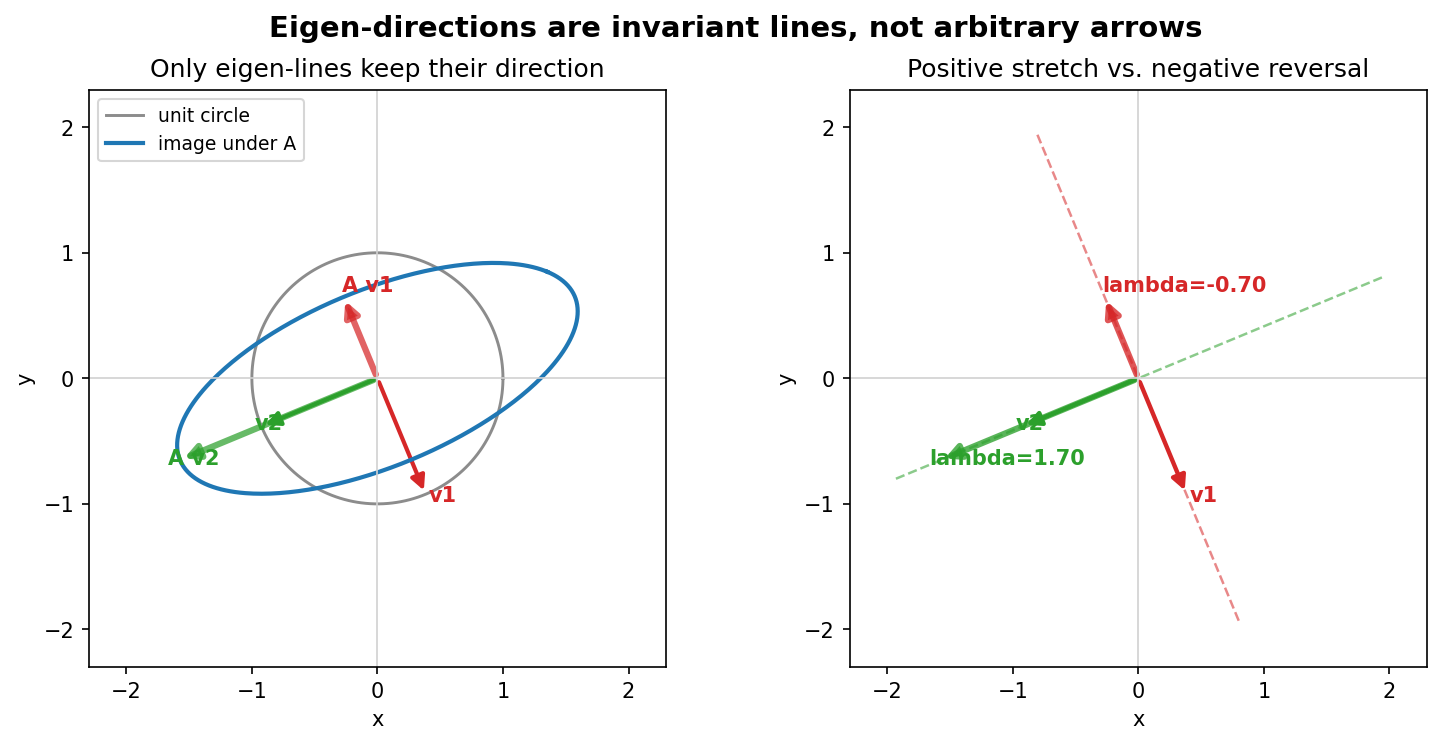

{'eigenvalues': [-0.7020815280171308, 1.7020815280171309],
 'max_residual': 1.1102230246251565e-16,
 'has_negative_eigenvalue': True}

In [2]:
A_eigen = np.array([[1.35, 0.85], [0.85, -0.35]], dtype=float)
evals_eigen, evecs_eigen = eigh(A_eigen)
angles = np.linspace(0, 2 * np.pi, 360, endpoint=True)
circle = np.vstack([np.cos(angles), np.sin(angles)])
transformed = A_eigen @ circle

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(circle[0], circle[1], color="0.55", linewidth=1.4, label="unit circle")
axes[0].plot(transformed[0], transformed[1], color="#1f77b4", linewidth=2.0, label="image under A")
for i, color in enumerate(["#d62728", "#2ca02c"]):
    v = evecs_eigen[:, i]
    Av = A_eigen @ v
    draw_arrow(axes[0], (0, 0), v, color, label=f"v{i+1}", lw=2.0)
    draw_arrow(axes[0], (0, 0), Av, color, label=f"A v{i+1}", lw=3.0, alpha=0.72)
axes[0].set_title("Only eigen-lines keep their direction")
axes[0].legend(loc="upper left", fontsize=9)
set_equal_frame(axes[0], limit=2.3)

for i, color in enumerate(["#d62728", "#2ca02c"]):
    v = evecs_eigen[:, i]
    Av = A_eigen @ v
    line = np.column_stack([-2.1 * v, 2.1 * v])
    axes[1].plot(line[0], line[1], color=color, linestyle="--", linewidth=1.2, alpha=0.55)
    draw_arrow(axes[1], (0, 0), v, color, label=f"v{i+1}", lw=2.1)
    draw_arrow(axes[1], (0, 0), Av, color, label=f"lambda={evals_eigen[i]:.2f}", lw=3.0, alpha=0.78)
axes[1].set_title("Positive stretch vs. negative reversal")
set_equal_frame(axes[1], limit=2.3)
fig.suptitle("Eigen-directions are invariant lines, not arbitrary arrows", fontsize=14, weight="bold")

path = register(save_matplotlib(fig, TOPIC, "eigen-directions-stretch-sign.png", root=ARTIFACT_LIBRARY_ROOT))
plt.close(fig)

residuals = [np.linalg.norm(A_eigen @ evecs_eigen[:, i] - evals_eigen[i] * evecs_eigen[:, i]) for i in range(2)]
checks["eigen_directions"] = {
    "eigenvalues": [as_float(x) for x in evals_eigen],
    "max_residual": max(as_float(r) for r in residuals),
    "has_negative_eigenvalue": bool(np.any(evals_eigen < 0)),
}
display_book_artifact(path, width=900)
checks["eigen_directions"]


## 2. Self-Adjoint Spectra: Why Orthogonal Modes Appear

The source span proves two properties before stating the compact spectral theorem: self-adjoint operators have real eigenvalues, and eigenfunctions for distinct eigenvalues are orthogonal. In code, a real symmetric matrix or a complex Hermitian matrix is the finite model.

The proof graph records the logical dependency. The matrix panel checks the same claim numerically: the eigenvector Gram matrix is the identity, so coefficient coordinates do not leak between modes.


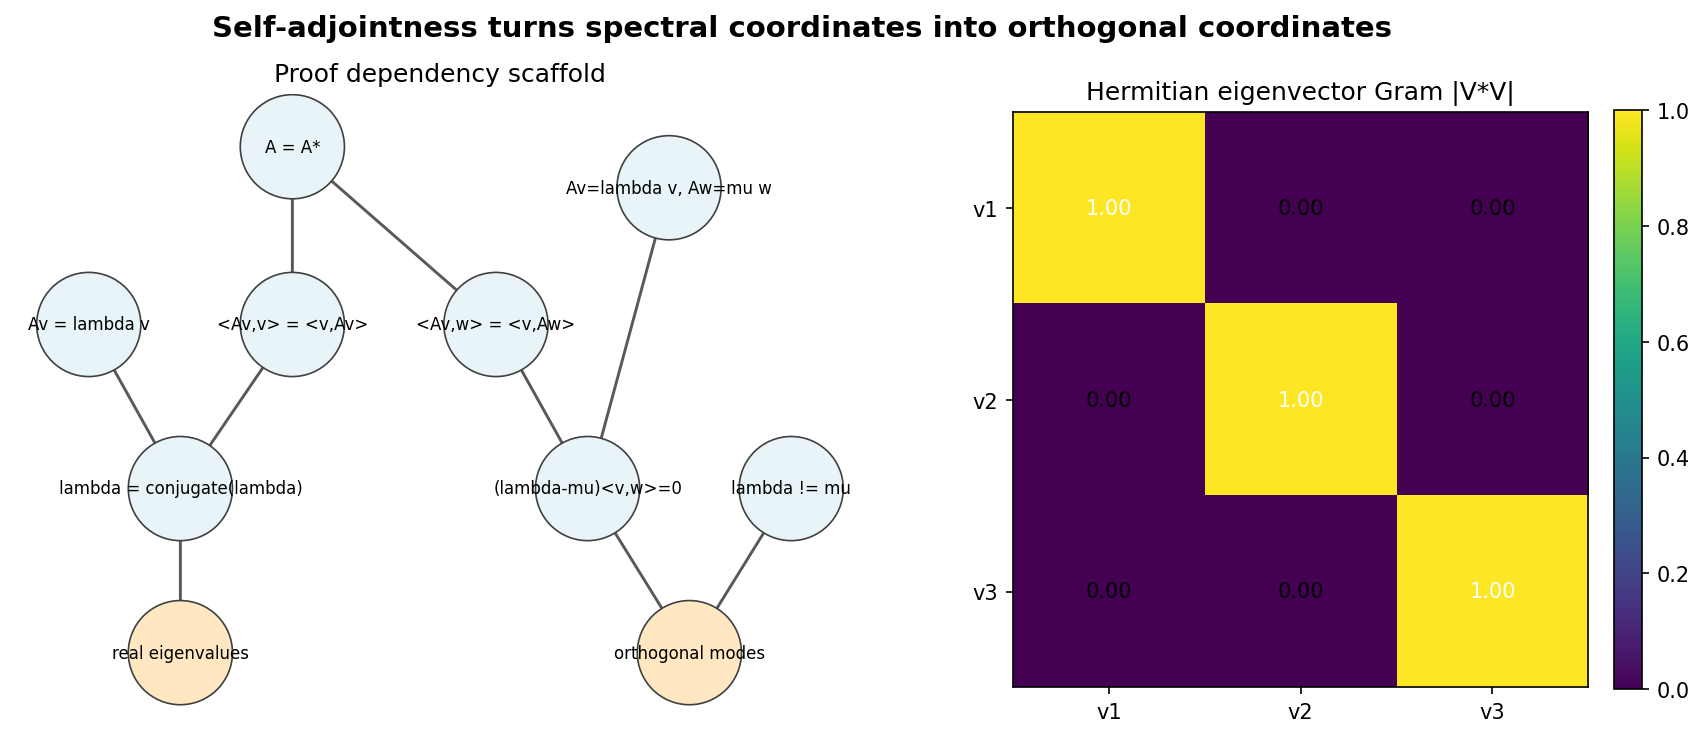

{'hermitian_residual': 0.0,
 'max_imaginary_eigenvalue': 0.0,
 'gram_identity_residual': 6.86985540511656e-16,
 'eigenvalues': [1.077796813059876, 1.8199758084301065, 3.6022273785100163]}

In [3]:
H = np.array(
    [[2.0, 0.7 + 0.4j, -0.2j], [0.7 - 0.4j, 3.1, 0.5], [0.2j, 0.5, 1.4]],
    dtype=complex,
)
evals_H, evecs_H = eigh(H)
gram_H = evecs_H.conj().T @ evecs_H

G_proof = nx.DiGraph()
G_proof.add_edges_from([
    ("A = A*", "<Av,v> = <v,Av>"),
    ("Av = lambda v", "lambda = conjugate(lambda)"),
    ("<Av,v> = <v,Av>", "lambda = conjugate(lambda)"),
    ("lambda = conjugate(lambda)", "real eigenvalues"),
    ("A = A*", "<Av,w> = <v,Aw>"),
    ("Av=lambda v, Aw=mu w", "(lambda-mu)<v,w>=0"),
    ("<Av,w> = <v,Aw>", "(lambda-mu)<v,w>=0"),
    ("lambda != mu", "orthogonal modes"),
    ("(lambda-mu)<v,w>=0", "orthogonal modes"),
])
pos = {
    "A = A*": (0.0, 1.0),
    "Av = lambda v": (-1.0, 0.35),
    "<Av,v> = <v,Av>": (0.0, 0.35),
    "lambda = conjugate(lambda)": (-0.55, -0.25),
    "real eigenvalues": (-0.55, -0.85),
    "<Av,w> = <v,Aw>": (1.0, 0.35),
    "Av=lambda v, Aw=mu w": (1.85, 0.85),
    "(lambda-mu)<v,w>=0": (1.45, -0.25),
    "lambda != mu": (2.45, -0.25),
    "orthogonal modes": (1.95, -0.85),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.3), gridspec_kw={"width_ratios": [1.35, 1.0]})
node_colors = ["#e8f4f8" if "orthogonal" not in node and "real" not in node else "#ffe7c2" for node in G_proof.nodes]
nx.draw_networkx_edges(G_proof, pos, ax=axes[0], arrows=True, arrowstyle="-|>", arrowsize=12, width=1.4, edge_color="0.35")
nx.draw_networkx_nodes(G_proof, pos, ax=axes[0], node_size=2500, node_color=node_colors, edgecolors="0.25", linewidths=0.8)
nx.draw_networkx_labels(G_proof, pos, ax=axes[0], font_size=8)
axes[0].set_title("Proof dependency scaffold")
axes[0].axis("off")

image = axes[1].imshow(np.abs(gram_H), vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Hermitian eigenvector Gram |V*V|")
axes[1].set_xticks(range(3), ["v1", "v2", "v3"])
axes[1].set_yticks(range(3), ["v1", "v2", "v3"])
for i in range(3):
    for j in range(3):
        value = abs(gram_H[i, j])
        axes[1].text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.45 else "black")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
fig.suptitle("Self-adjointness turns spectral coordinates into orthogonal coordinates", fontsize=14, weight="bold")

path = register(save_matplotlib(fig, TOPIC, "self-adjoint-spectrum-orthogonality.png", root=ARTIFACT_LIBRARY_ROOT))
plt.close(fig)

checks["self_adjoint_spectrum"] = {
    "hermitian_residual": as_float(np.linalg.norm(H - H.conj().T)),
    "max_imaginary_eigenvalue": as_float(np.max(np.abs(evals_H.imag))),
    "gram_identity_residual": as_float(np.linalg.norm(gram_H - np.eye(3))),
    "eigenvalues": [as_float(x) for x in evals_H],
}
display_book_artifact(path, width=980)
checks["self_adjoint_spectrum"]


## 3. Periodic Laplacian Eigenfunctions

On the circle, the complex exponentials `exp(i n x)` are Laplacian eigenfunctions. The continuum statement is `d^2/dx^2 exp(i n x) = -n^2 exp(i n x)`. A periodic finite-difference Laplacian gives the same idea on a grid, with eigenvalues close to `-n^2` for low frequencies.

The important inspection target is not the exact formula alone. It is that each mode keeps its shape under the operator while only its multiplier changes.


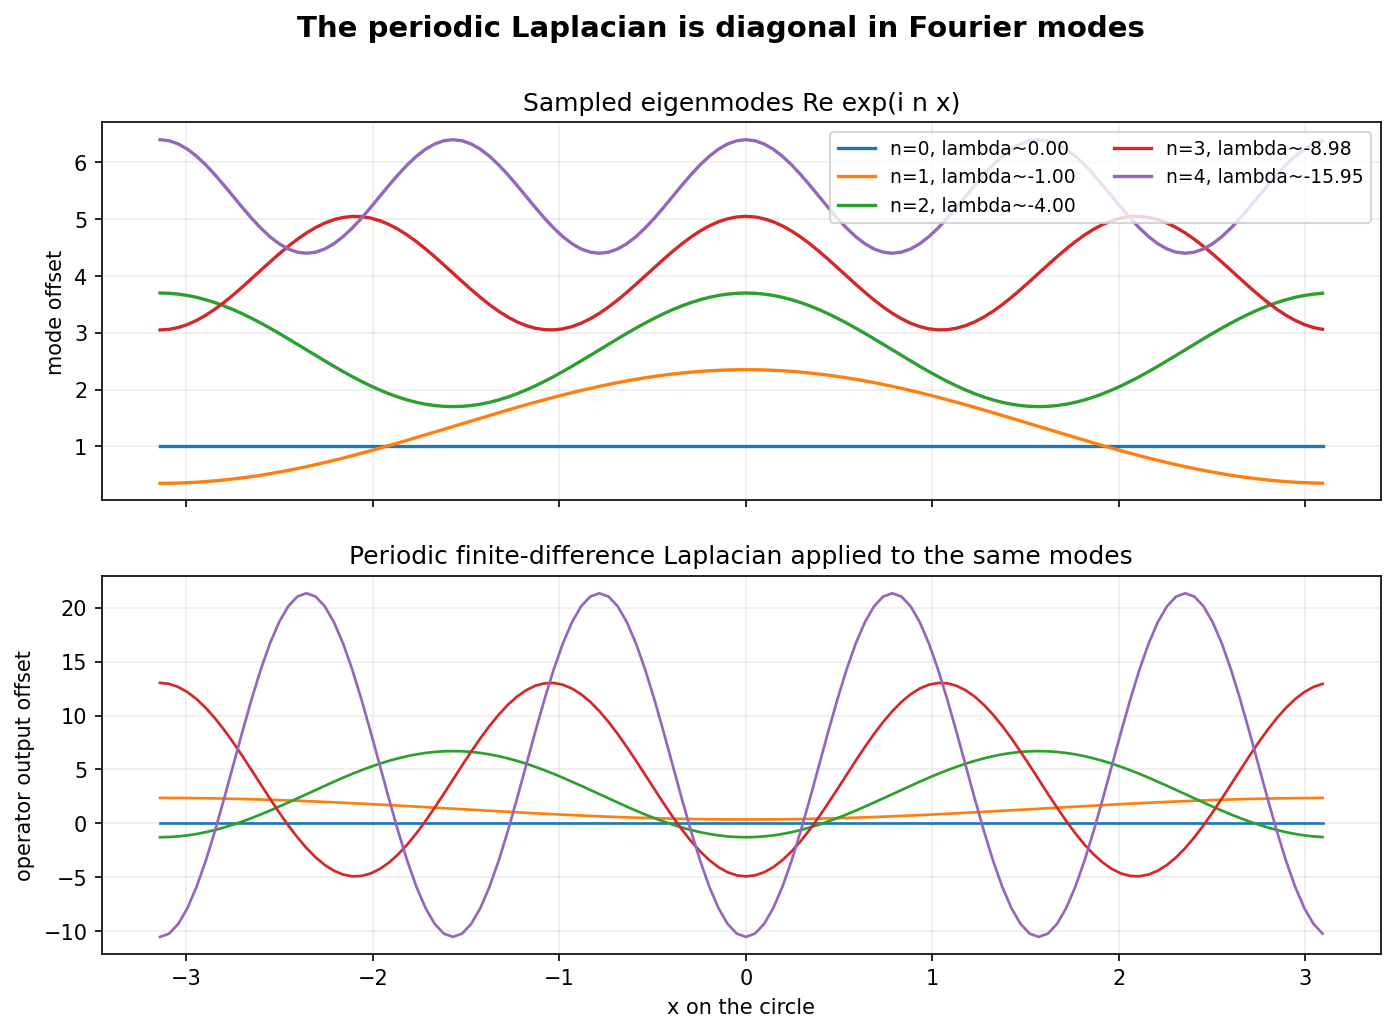

[{'n': 0, 'continuous_lambda': 0.0, 'discrete_lambda': 0.0, 'residual': 0.0},
 {'n': 1,
  'continuous_lambda': -1.0,
  'discrete_lambda': -0.9997992185115937,
  'residual': 1.9434699317417469e-13},
 {'n': 2,
  'continuous_lambda': -4.0,
  'discrete_lambda': -3.996788270156917,
  'residual': 3.6548719930920936e-13}]

In [4]:
N_lap = 128
x_lap = np.linspace(-np.pi, np.pi, N_lap, endpoint=False)
dx = x_lap[1] - x_lap[0]
L_periodic = (np.roll(np.eye(N_lap), 1, axis=1) + np.roll(np.eye(N_lap), -1, axis=1) - 2 * np.eye(N_lap)) / (dx ** 2)
mode_numbers = np.arange(0, 6)
mode_rows = []

fig, axes = plt.subplots(2, 1, figsize=(11, 7.2), sharex=True)
for n in mode_numbers:
    phi = np.exp(1j * n * x_lap)
    lambda_discrete = (2 * np.cos(n * dx) - 2) / (dx ** 2)
    residual = np.linalg.norm(L_periodic @ phi - lambda_discrete * phi) / np.linalg.norm(phi)
    mode_rows.append({
        "n": int(n),
        "continuous_lambda": float(-(n ** 2)),
        "discrete_lambda": float(lambda_discrete),
        "residual": float(residual),
    })
    if n <= 4:
        axes[0].plot(x_lap, phi.real + 1.35 * n, linewidth=1.6, label=f"n={n}, lambda~{lambda_discrete:.2f}")
        axes[1].plot(x_lap, (L_periodic @ phi).real + 1.35 * n, linewidth=1.3)
axes[0].set_title("Sampled eigenmodes Re exp(i n x)")
axes[0].set_ylabel("mode offset")
axes[0].legend(ncol=2, fontsize=9)
axes[1].set_title("Periodic finite-difference Laplacian applied to the same modes")
axes[1].set_xlabel("x on the circle")
axes[1].set_ylabel("operator output offset")
for ax in axes:
    ax.grid(True, alpha=0.22)
fig.suptitle("The periodic Laplacian is diagonal in Fourier modes", fontsize=14, weight="bold")

path = register(save_matplotlib(fig, TOPIC, "periodic-laplacian-eigenmodes.png", root=ARTIFACT_LIBRARY_ROOT))
plt.close(fig)

checks["periodic_laplacian"] = {
    "max_mode_residual": max(row["residual"] for row in mode_rows),
    "low_frequency_lambda_error_n1": abs(mode_rows[1]["continuous_lambda"] - mode_rows[1]["discrete_lambda"]),
    "mode_rows": mode_rows,
}
display_book_artifact(path, width=900)
checks["periodic_laplacian"]["mode_rows"][:3]


## 4. Fourier Gram Matrices and Reconstruction

Fourier analysis is the same diagonal-coordinate idea applied to functions. If the basis is orthonormal, its Gram matrix is the Kronecker delta: diagonal entries are one and off-diagonal entries vanish. Coefficients are then inner products with basis modes, and reconstruction is matrix multiplication by the basis.

The heatmap should look like an identity matrix. The coefficient bars should be nonzero exactly where the signal contains frequency content.


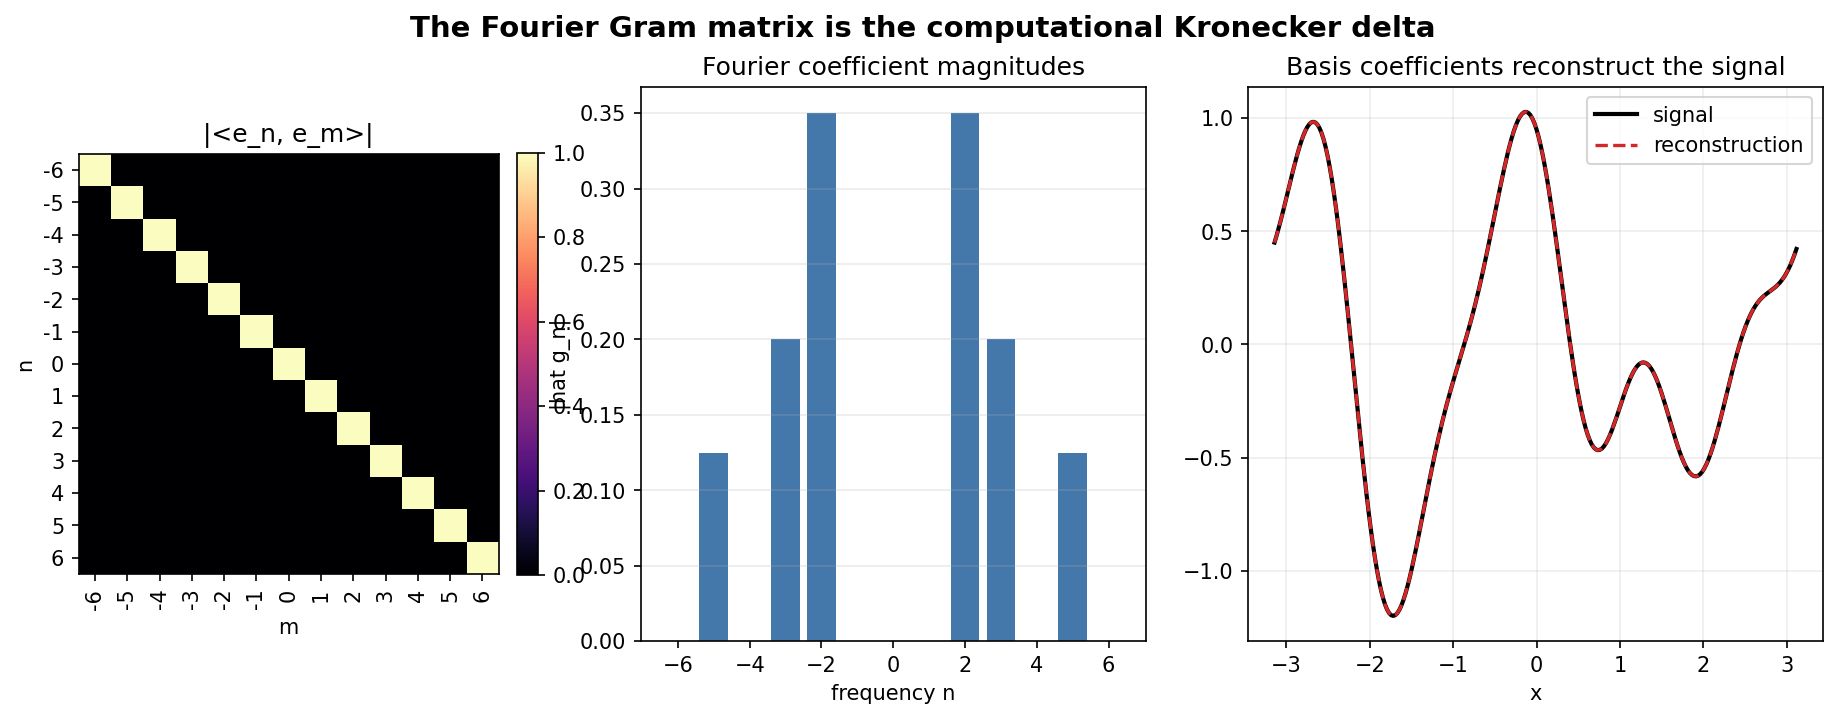

{'gram_identity_residual': 9.547802781560377e-16,
 'reconstruction_error': 1.7336808068517413e-16,
 'dominant_frequencies': [-5, -3, -2, 2, 3, 5]}

In [5]:
N_fourier = 256
x_fourier = np.linspace(-np.pi, np.pi, N_fourier, endpoint=False)
freqs = np.arange(-6, 7)
Phi = np.exp(1j * np.outer(x_fourier, freqs))
Gram = Phi.conj().T @ Phi / N_fourier
signal_fourier = 0.70 * np.cos(2 * x_fourier) - 0.40 * np.sin(3 * x_fourier) + 0.25 * np.cos(5 * x_fourier)
coeffs_fourier = Phi.conj().T @ signal_fourier / N_fourier
reconstruction_fourier = (Phi @ coeffs_fourier).real

coefficient_rows = []
for n, coeff in zip(freqs, coeffs_fourier):
    coefficient_rows.append({
        "frequency": int(n),
        "real": float(coeff.real),
        "imag": float(coeff.imag),
        "magnitude": float(abs(coeff)),
    })
table_path = register(save_table_csv(coefficient_rows, TOPIC, "fourier-coefficient-ledger.csv", root=ARTIFACT_LIBRARY_ROOT))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.0, 1.1, 1.25]})
heat = axes[0].imshow(np.abs(Gram), vmin=0, vmax=1, cmap="magma")
axes[0].set_title("|<e_n, e_m>|")
axes[0].set_xticks(range(len(freqs)), freqs, rotation=90)
axes[0].set_yticks(range(len(freqs)), freqs)
axes[0].set_xlabel("m")
axes[0].set_ylabel("n")
fig.colorbar(heat, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].bar(freqs, np.abs(coeffs_fourier), color="#4477aa")
axes[1].set_title("Fourier coefficient magnitudes")
axes[1].set_xlabel("frequency n")
axes[1].set_ylabel("|hat g_n|")
axes[1].grid(axis="y", alpha=0.25)

axes[2].plot(x_fourier, signal_fourier, color="black", linewidth=2.0, label="signal")
axes[2].plot(x_fourier, reconstruction_fourier, color="#d62728", linestyle="--", linewidth=1.6, label="reconstruction")
axes[2].set_title("Basis coefficients reconstruct the signal")
axes[2].set_xlabel("x")
axes[2].legend()
axes[2].grid(alpha=0.22)
fig.suptitle("The Fourier Gram matrix is the computational Kronecker delta", fontsize=14, weight="bold")

path = register(save_matplotlib(fig, TOPIC, "fourier-gram-kronecker-delta.png", root=ARTIFACT_LIBRARY_ROOT))
plt.close(fig)

checks["fourier_gram"] = {
    "gram_identity_residual": as_float(np.linalg.norm(Gram - np.eye(len(freqs)))),
    "reconstruction_error": as_float(np.linalg.norm(signal_fourier - reconstruction_fourier) / np.linalg.norm(signal_fourier)),
    "dominant_frequencies": [int(row["frequency"]) for row in coefficient_rows if row["magnitude"] > 0.1],
}
display_book_artifact(path, width=1000)
display_book_artifact(table_path)
checks["fourier_gram"]


## 5. SVD: Spectral Coordinates Without Self-Adjointness

The spectral theorem is built for self-adjoint operators. A general matrix may rotate and shear so that no real direction is simply scaled. Singular value decomposition solves a different problem: it finds orthonormal directions in the domain that map to orthonormal directions in the codomain, with nonnegative stretch factors.

In the picture, each right singular vector `v_i` starts on the unit circle. The matrix sends it to `sigma_i u_i`, which lies on the transformed ellipse.


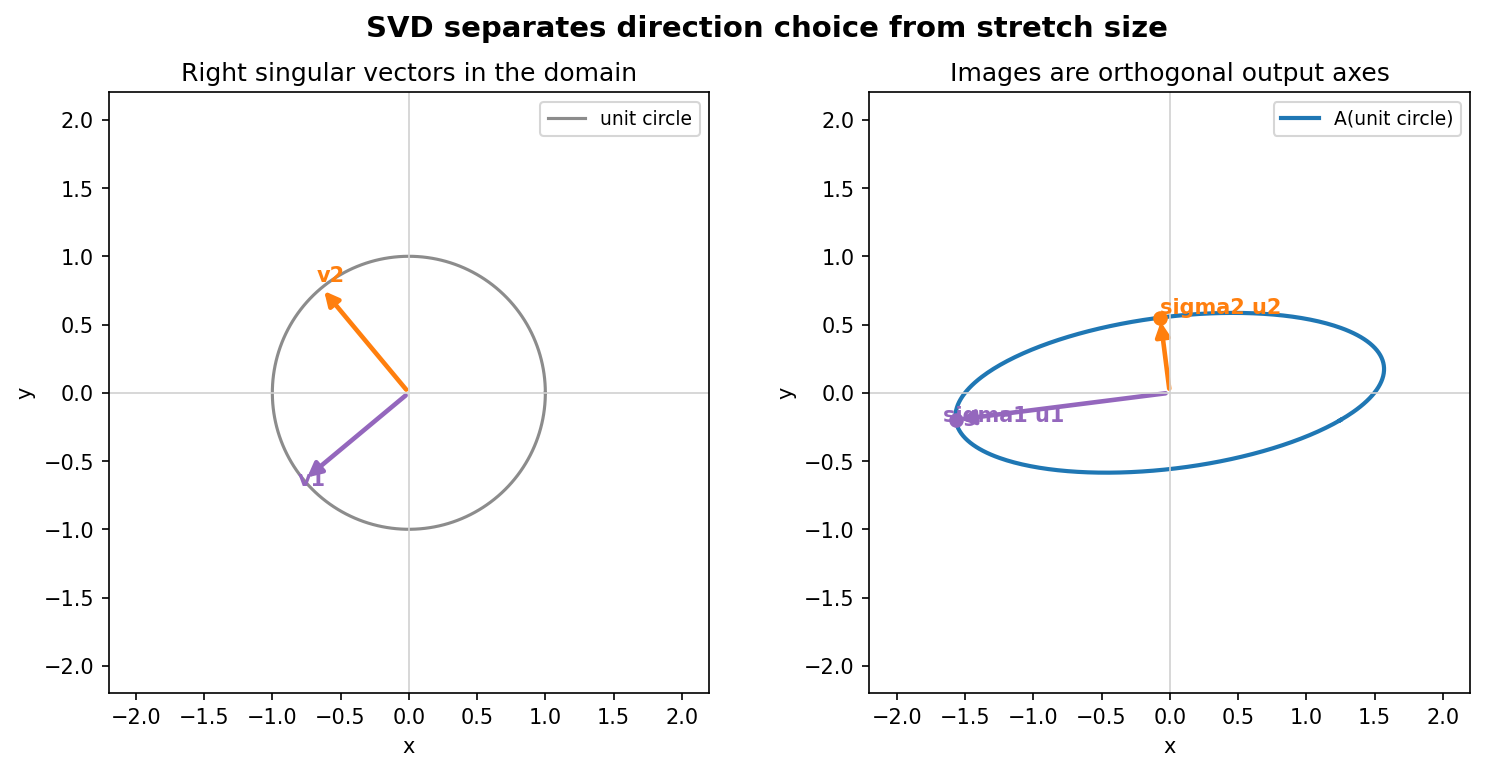

{'reconstruction_residual': 3.510833468576701e-16,
 'direction_residual': 3.0436364816617974e-16,
 'singular_values': [1.5809575813817711, 0.5550433549476118],
 'rotation_eigenvalues_abs': [0.9999999999999999, 0.9999999999999999],
 'rotation_singular_values': [1.0, 0.9999999999999999]}

In [6]:
A_svd = np.array([[1.25, 0.95], [-0.20, 0.55]], dtype=float)
U_svd, sigma_svd, Vt_svd = svd(A_svd)
V_svd = Vt_svd.T
circle_svd = np.vstack([np.cos(angles), np.sin(angles)])
ellipse_svd = A_svd @ circle_svd

rotation_angle = np.deg2rad(65)
R = np.array([[np.cos(rotation_angle), -np.sin(rotation_angle)], [np.sin(rotation_angle), np.cos(rotation_angle)]])
rotation_eigs = np.linalg.eigvals(R)
rotation_singular_values = svd(R, compute_uv=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
axes[0].plot(circle_svd[0], circle_svd[1], color="0.55", label="unit circle")
for i, color in enumerate(["#9467bd", "#ff7f0e"]):
    draw_arrow(axes[0], (0, 0), V_svd[:, i], color, label=f"v{i+1}")
axes[0].set_title("Right singular vectors in the domain")
axes[0].legend(fontsize=9)
set_equal_frame(axes[0], limit=2.2)

axes[1].plot(ellipse_svd[0], ellipse_svd[1], color="#1f77b4", linewidth=2.0, label="A(unit circle)")
for i, color in enumerate(["#9467bd", "#ff7f0e"]):
    image_vec = A_svd @ V_svd[:, i]
    target_vec = sigma_svd[i] * U_svd[:, i]
    draw_arrow(axes[1], (0, 0), image_vec, color, label=f"sigma{i+1} u{i+1}")
    axes[1].plot([target_vec[0]], [target_vec[1]], marker="o", color=color)
axes[1].set_title("Images are orthogonal output axes")
axes[1].legend(fontsize=9)
set_equal_frame(axes[1], limit=2.2)
fig.suptitle("SVD separates direction choice from stretch size", fontsize=14, weight="bold")

path = register(save_matplotlib(fig, TOPIC, "svd-stretch-directions.png", root=ARTIFACT_LIBRARY_ROOT))
plt.close(fig)

Sigma_svd = np.zeros_like(A_svd)
np.fill_diagonal(Sigma_svd, sigma_svd)
checks["svd"] = {
    "reconstruction_residual": as_float(np.linalg.norm(A_svd - U_svd @ Sigma_svd @ Vt_svd)),
    "direction_residual": as_float(max(np.linalg.norm(A_svd @ V_svd[:, i] - sigma_svd[i] * U_svd[:, i]) for i in range(2))),
    "singular_values": [as_float(x) for x in sigma_svd],
    "rotation_eigenvalues_abs": [as_float(abs(x)) for x in rotation_eigs],
    "rotation_singular_values": [as_float(x) for x in rotation_singular_values],
}
display_book_artifact(path, width=900)
checks["svd"]


## 6. Parseval: Energy Survives the Coordinate Change

Fourier coefficients are useful only because the basis change preserves geometry. Parseval's identity says that the squared norm of a signal equals the sum of squared coefficient magnitudes. In finite dimensions this is the statement that a unitary matrix preserves inner products.

The figure uses a unitary discrete Fourier matrix. The left panel is the signal, the center panel is coefficient energy by frequency, and the right panel is the equality check.


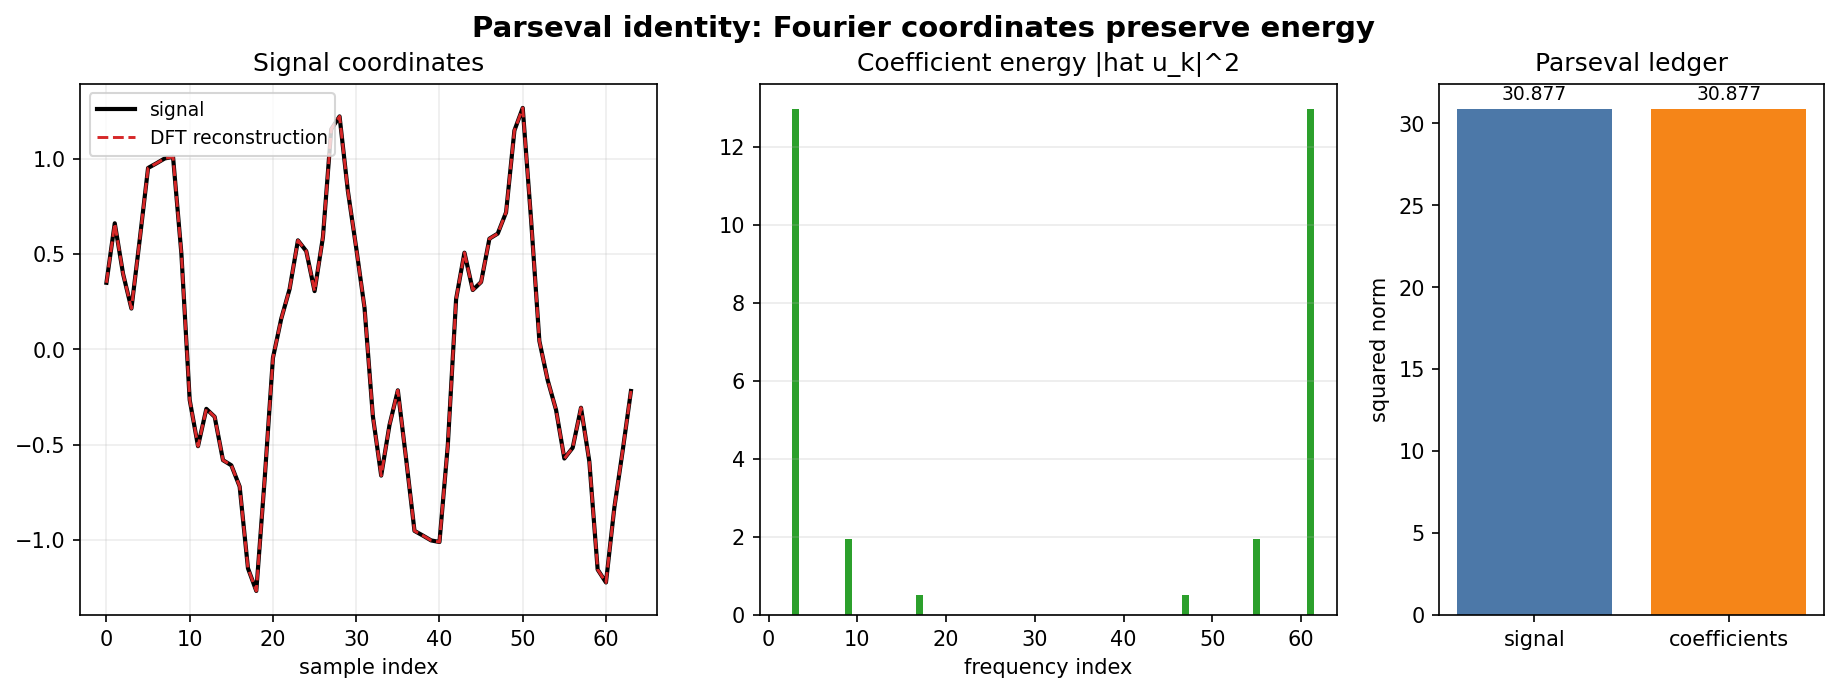

{'unitary_residual': 7.169895842827217e-14,
 'energy_signal': 30.876799999999996,
 'energy_coefficients': 30.87679999999997,
 'energy_gap': 2.4868995751603507e-14,
 'reconstruction_error': 7.148277737700943e-15,
 'partial_reconstruction_errors': [0.40066790543108644,
  0.18324467026983124,
  5.514149224908101e-15,
  6.792174495089823e-15,
  6.8954437129162626e-15,
  7.148277737700943e-15]}

In [7]:
N_parseval = 64
j = np.arange(N_parseval)
u_parseval = (
    0.9 * np.sin(2 * np.pi * 3 * j / N_parseval)
    + 0.35 * np.cos(2 * np.pi * 9 * j / N_parseval)
    + 0.18 * np.sin(2 * np.pi * 17 * j / N_parseval)
)
F = np.exp(2j * np.pi * np.outer(j, j) / N_parseval) / np.sqrt(N_parseval)
coeff_parseval = F.conj().T @ u_parseval
u_reconstructed = (F @ coeff_parseval).real
energy_signal = float(np.vdot(u_parseval, u_parseval).real)
energy_coeff = float(np.vdot(coeff_parseval, coeff_parseval).real)
coefficient_energy = np.abs(coeff_parseval) ** 2
largest_order = np.argsort(coefficient_energy)[::-1]
partial_errors = []
for keep in [2, 4, 8, 16, 32, 64]:
    mask = np.zeros(N_parseval, dtype=bool)
    mask[largest_order[:keep]] = True
    partial = (F @ (coeff_parseval * mask)).real
    partial_errors.append(float(np.linalg.norm(u_parseval - partial) / np.linalg.norm(u_parseval)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.2, 1.2, 0.8]})
axes[0].plot(j, u_parseval, color="black", linewidth=2.0, label="signal")
axes[0].plot(j, u_reconstructed, color="#d62728", linestyle="--", linewidth=1.4, label="DFT reconstruction")
axes[0].set_title("Signal coordinates")
axes[0].set_xlabel("sample index")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.22)

axes[1].bar(np.arange(N_parseval), coefficient_energy, color="#2ca02c")
axes[1].set_title("Coefficient energy |hat u_k|^2")
axes[1].set_xlabel("frequency index")
axes[1].set_xlim(-1, N_parseval)
axes[1].grid(axis="y", alpha=0.25)

axes[2].bar(["signal", "coefficients"], [energy_signal, energy_coeff], color=["#4c78a8", "#f58518"])
axes[2].set_title("Parseval ledger")
axes[2].set_ylabel("squared norm")
for idx, value in enumerate([energy_signal, energy_coeff]):
    axes[2].text(idx, value * 1.01, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
fig.suptitle("Parseval identity: Fourier coordinates preserve energy", fontsize=14, weight="bold")

path = register(save_matplotlib(fig, TOPIC, "parseval-energy-ledger.png", root=ARTIFACT_LIBRARY_ROOT))
plt.close(fig)

checks["parseval"] = {
    "unitary_residual": as_float(np.linalg.norm(F.conj().T @ F - np.eye(N_parseval))),
    "energy_signal": energy_signal,
    "energy_coefficients": energy_coeff,
    "energy_gap": abs(energy_signal - energy_coeff),
    "reconstruction_error": as_float(np.linalg.norm(u_parseval - u_reconstructed) / np.linalg.norm(u_parseval)),
    "partial_reconstruction_errors": partial_errors,
}
display_book_artifact(path, width=1000)
checks["parseval"]


## 7. Heat Flow: The Laplacian as a Frequency-Selective Filter

The heat equation becomes simple in the Laplacian eigenbasis. If a mode has eigenvalue `-n^2`, then its coefficient is multiplied by `exp(-n^2 t)`. Large `|n|` modes decay fastest. The constant mode has eigenvalue zero, so it preserves the average temperature.

The PNG gives a static inspection view. The HTML artifact lets you move through time and watch the same spectral filter smooth the signal.


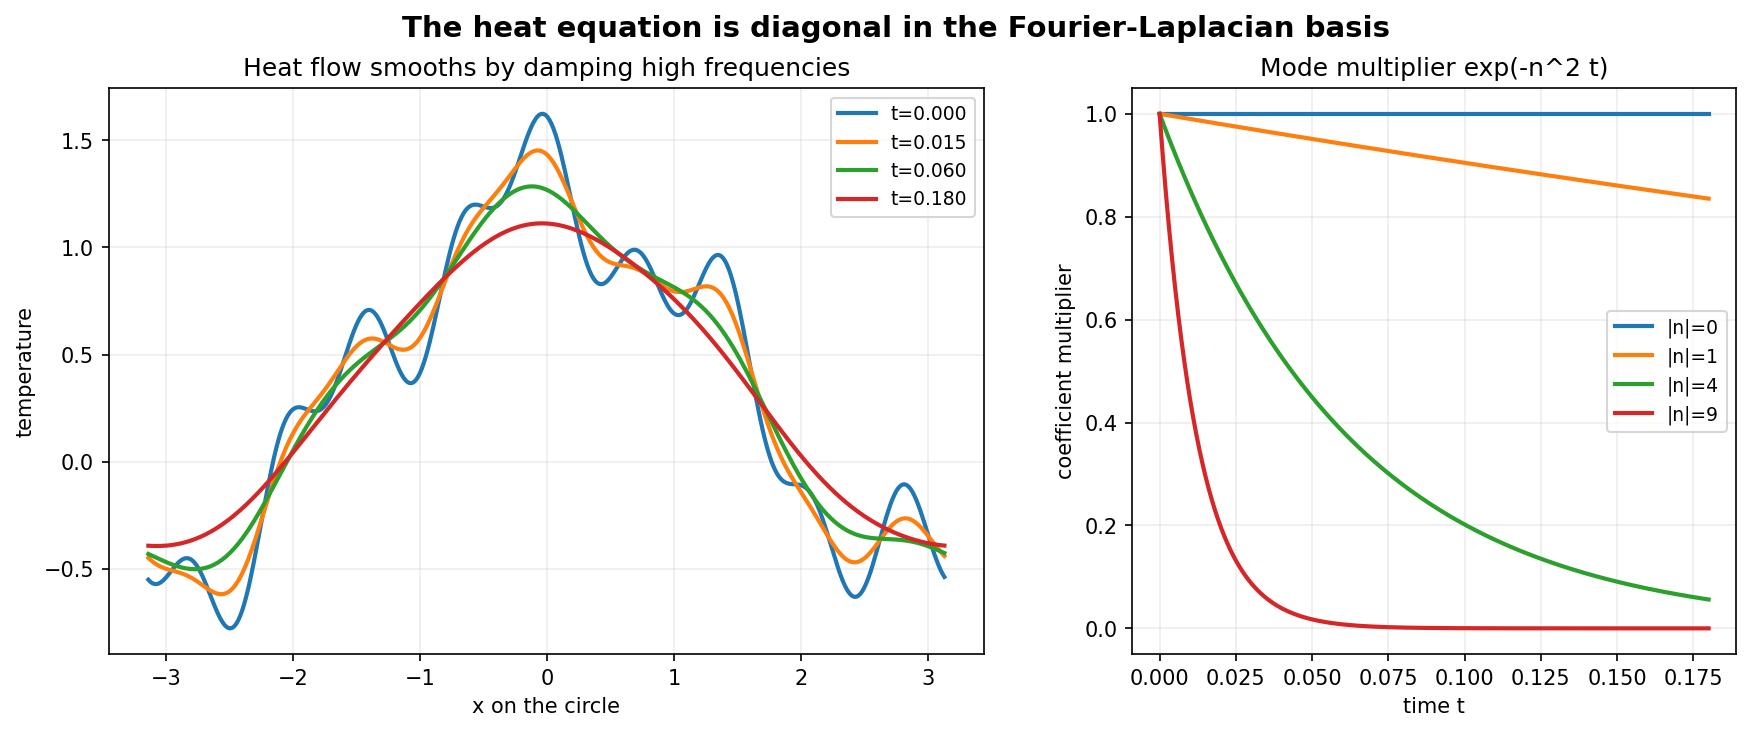

{'energies': [0.5761,
  0.5370052196694992,
  0.486453815577481,
  0.4051610080745606],
 'means': [0.35, 0.35, 0.3499999999999999, 0.34999999999999987],
 'energy_nonincreasing': True,
 'mean_max_deviation': 1.1102230246251565e-16,
 'mode_decay': {0: [1.0, 1.0, 1.0, 1.0],
  1: [1.0, 0.9851119396030626, 0.9417645335842487, 0.835270211411272],
  4: [1.0, 0.7866278610665535, 0.38289288597511206, 0.056134762834133725],
  9: [1.0, 0.2967100142940453, 0.007750483891136699, 4.6557157157830866e-07]}}

In [8]:
K_heat = 12
freqs_heat = np.arange(-K_heat, K_heat + 1)
x_heat = np.linspace(-np.pi, np.pi, 400, endpoint=False)
coeff_heat = np.zeros(len(freqs_heat), dtype=complex)
for idx, n in enumerate(freqs_heat):
    if n == 0:
        coeff_heat[idx] = 0.35
    elif abs(n) == 1:
        coeff_heat[idx] = 0.45
    elif abs(n) == 4:
        coeff_heat[idx] = 0.18 * (1 if n > 0 else -1j)
    elif abs(n) == 9:
        coeff_heat[idx] = 0.09
basis_heat = np.exp(1j * np.outer(x_heat, freqs_heat))


def heat_signal(t):
    damping = np.exp(-(freqs_heat ** 2) * t)
    return (basis_heat @ (coeff_heat * damping)).real


times_heat = [0.0, 0.015, 0.06, 0.18]
heat_curves = [heat_signal(t) for t in times_heat]
mode_decay = {int(n): [float(np.exp(-(n ** 2) * t)) for t in times_heat] for n in [0, 1, 4, 9]}
energies_heat = [float(np.mean(curve ** 2)) for curve in heat_curves]
means_heat = [float(np.mean(curve)) for curve in heat_curves]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.9), gridspec_kw={"width_ratios": [1.45, 1.0]})
for t, curve in zip(times_heat, heat_curves):
    axes[0].plot(x_heat, curve, linewidth=2.0, label=f"t={t:.3f}")
axes[0].set_title("Heat flow smooths by damping high frequencies")
axes[0].set_xlabel("x on the circle")
axes[0].set_ylabel("temperature")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.22)

for n in [0, 1, 4, 9]:
    t_grid = np.linspace(0, 0.18, 180)
    axes[1].plot(t_grid, np.exp(-(n ** 2) * t_grid), linewidth=2.0, label=f"|n|={n}")
axes[1].set_title("Mode multiplier exp(-n^2 t)")
axes[1].set_xlabel("time t")
axes[1].set_ylabel("coefficient multiplier")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.22)
fig.suptitle("The heat equation is diagonal in the Fourier-Laplacian basis", fontsize=14, weight="bold")

path = register(save_matplotlib(fig, TOPIC, "heat-equation-mode-decay.png", root=ARTIFACT_LIBRARY_ROOT))
plt.close(fig)

slider_times = np.linspace(0, 0.20, 41)
frames = [go.Frame(data=[go.Scatter(x=x_heat, y=heat_signal(float(t)), mode="lines")], name=f"{t:.3f}") for t in slider_times]
fig_html = go.Figure(
    data=[go.Scatter(x=x_heat, y=heat_signal(0.0), mode="lines", line={"color": "#1f77b4", "width": 3})],
    frames=frames,
)
fig_html.update_layout(
    title="Heat flow on the circle as spectral damping",
    xaxis_title="x",
    yaxis_title="temperature",
    yaxis={"range": [min(map(np.min, heat_curves)) - 0.15, max(map(np.max, heat_curves)) + 0.15]},
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "time t = "},
        "steps": [{"label": f"{t:.3f}", "method": "animate", "args": [[f"{t:.3f}"], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]} for t in slider_times],
    }],
    updatemenus=[{"type": "buttons", "buttons": [{"label": "Play", "method": "animate", "args": [None, {"frame": {"duration": 70, "redraw": True}, "fromcurrent": True}]}, {"label": "Pause", "method": "animate", "args": [[None], {"mode": "immediate"}]}]}],
)
html_path = register(save_plotly_html(fig_html, TOPIC, "heat-flow-spectral-slider.html", root=ARTIFACT_LIBRARY_ROOT, include_plotlyjs=True))

checks["heat_flow"] = {
    "energies": energies_heat,
    "means": means_heat,
    "energy_nonincreasing": bool(all(earlier >= later - 1e-12 for earlier, later in zip(energies_heat, energies_heat[1:]))),
    "mean_max_deviation": max(abs(m - means_heat[0]) for m in means_heat),
    "mode_decay": mode_decay,
}
display_book_artifact(path, width=1000)
display_book_artifact(html_path, width="100%", height=520)
checks["heat_flow"]


## 8. Graph Laplacian Bridge

For geometric deep learning, signals often live on graphs or meshes rather than on a line or circle with coordinates. A graph Laplacian supplies an operator whose eigenvectors play the role of Fourier modes. On a cycle graph, this is especially transparent: the graph is a finite circle, and its eigenvalues match the formula `2 - 2 cos(2 pi k / N)`.

The colors below are graph Fourier modes. Their signs can flip without changing the eigenspace, so the invariant is the subspace and eigenvalue, not a particular color orientation.


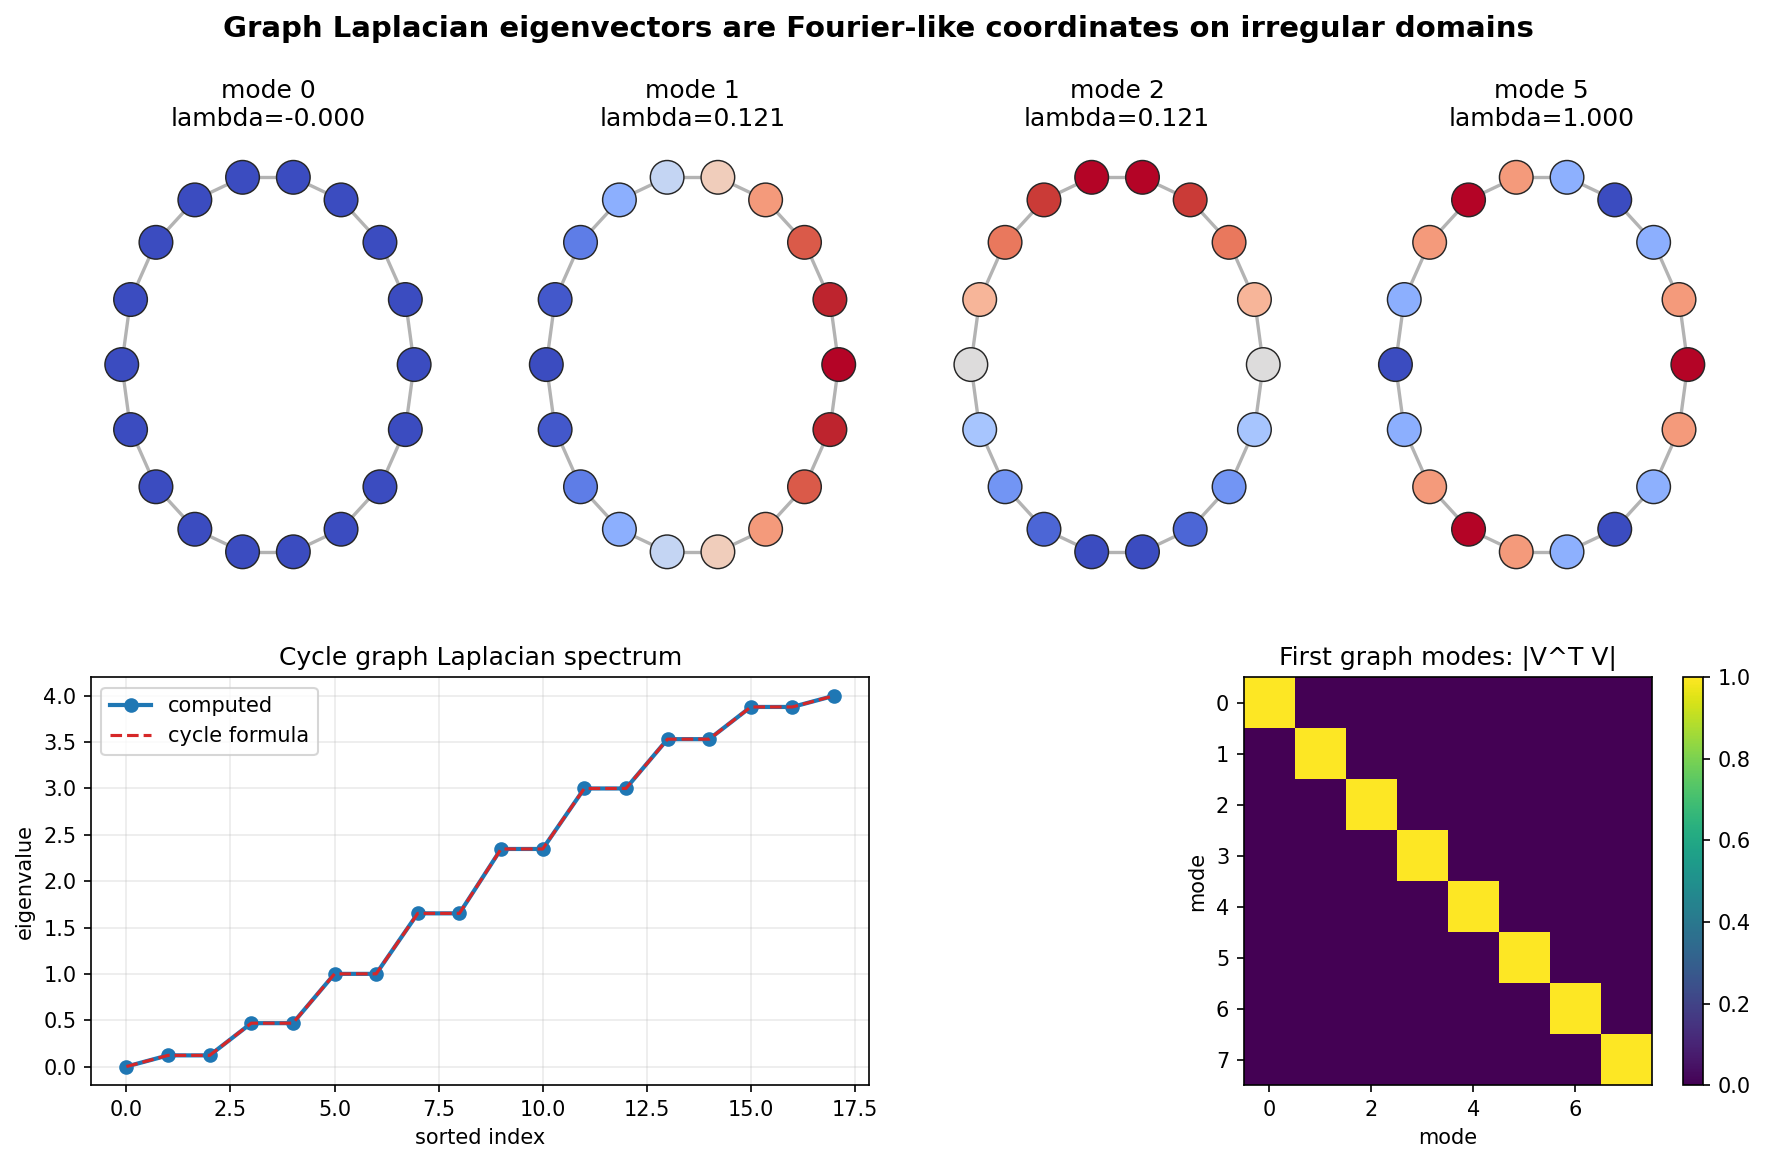

{'symmetry_residual': 0.0,
 'zero_eigenvalue': -1.9120518543201207e-16,
 'constant_mode_residual': 0.0,
 'cycle_formula_max_error': 4.218847493575595e-15,
 'orthonormality_residual': 5.8158403668077625e-15}

In [9]:
N_graph = 18
G_cycle = nx.cycle_graph(N_graph)
L_graph = nx.laplacian_matrix(G_cycle).toarray().astype(float)
evals_graph, evecs_graph = eigh(L_graph)
cycle_formula = np.sort(2 - 2 * np.cos(2 * np.pi * np.arange(N_graph) / N_graph))
pos_cycle = {node: (np.cos(2 * np.pi * node / N_graph), np.sin(2 * np.pi * node / N_graph)) for node in G_cycle.nodes}

spectrum_rows = []
for i, (computed, formula) in enumerate(zip(evals_graph, cycle_formula)):
    spectrum_rows.append({"index": int(i), "computed": float(computed), "cycle_formula": float(formula), "abs_error": float(abs(computed - formula))})
spectrum_path = register(save_table_csv(spectrum_rows, TOPIC, "graph-laplacian-spectrum.csv", root=ARTIFACT_LIBRARY_ROOT))

fig = plt.figure(figsize=(14, 8.2))
grid = fig.add_gridspec(2, 4, height_ratios=[1.0, 0.9])
mode_indices = [0, 1, 2, 5]
for col, mode_index in enumerate(mode_indices):
    ax = fig.add_subplot(grid[0, col])
    values = evecs_graph[:, mode_index]
    nx.draw_networkx_edges(G_cycle, pos_cycle, ax=ax, edge_color="0.70", width=1.6)
    nx.draw_networkx_nodes(
        G_cycle,
        pos_cycle,
        ax=ax,
        node_color=values,
        cmap="coolwarm",
        vmin=-np.max(np.abs(values)) if np.max(np.abs(values)) else -1,
        vmax=np.max(np.abs(values)) if np.max(np.abs(values)) else 1,
        node_size=260,
        edgecolors="0.15",
        linewidths=0.7,
    )
    ax.set_title(f"mode {mode_index}\nlambda={evals_graph[mode_index]:.3f}")
    ax.axis("off")

ax_spec = fig.add_subplot(grid[1, :2])
ax_spec.plot(range(N_graph), evals_graph, marker="o", linewidth=2.0, label="computed")
ax_spec.plot(range(N_graph), cycle_formula, linestyle="--", color="#d62728", label="cycle formula")
ax_spec.set_title("Cycle graph Laplacian spectrum")
ax_spec.set_xlabel("sorted index")
ax_spec.set_ylabel("eigenvalue")
ax_spec.legend()
ax_spec.grid(alpha=0.25)

ax_gram = fig.add_subplot(grid[1, 2:])
gram_graph = evecs_graph.T @ evecs_graph
image = ax_gram.imshow(np.abs(gram_graph[:8, :8]), vmin=0, vmax=1, cmap="viridis")
ax_gram.set_title("First graph modes: |V^T V|")
ax_gram.set_xlabel("mode")
ax_gram.set_ylabel("mode")
fig.colorbar(image, ax=ax_gram, fraction=0.046, pad=0.04)
fig.suptitle("Graph Laplacian eigenvectors are Fourier-like coordinates on irregular domains", fontsize=14, weight="bold")

path = register(save_matplotlib(fig, TOPIC, "graph-laplacian-fourier-bridge.png", root=ARTIFACT_LIBRARY_ROOT))
plt.close(fig)

checks["graph_laplacian_bridge"] = {
    "symmetry_residual": as_float(np.linalg.norm(L_graph - L_graph.T)),
    "zero_eigenvalue": as_float(evals_graph[0]),
    "constant_mode_residual": as_float(np.linalg.norm(L_graph @ np.ones(N_graph))),
    "cycle_formula_max_error": max(row["abs_error"] for row in spectrum_rows),
    "orthonormality_residual": as_float(np.linalg.norm(gram_graph - np.eye(N_graph))),
}
display_book_artifact(path, width=1000)
display_book_artifact(spectrum_path)
checks["graph_laplacian_bridge"]


## Applied lab: Heat Filtering a Graph Signal

The heat equation becomes a practical graph signal operation when `exp(-t L)` is applied to node features. Low graph frequencies survive; high graph frequencies are smoothed. This is one reason Laplacians show up in graph learning: they encode a locality and smoothness prior without requiring a coordinate chart.

In this lab, a noisy signal on a cycle graph is filtered spectrally. The sanity check is not subjective smoothness. It is the graph Dirichlet energy `f.T @ L @ f`, which should decrease after heat filtering while the mean stays fixed.


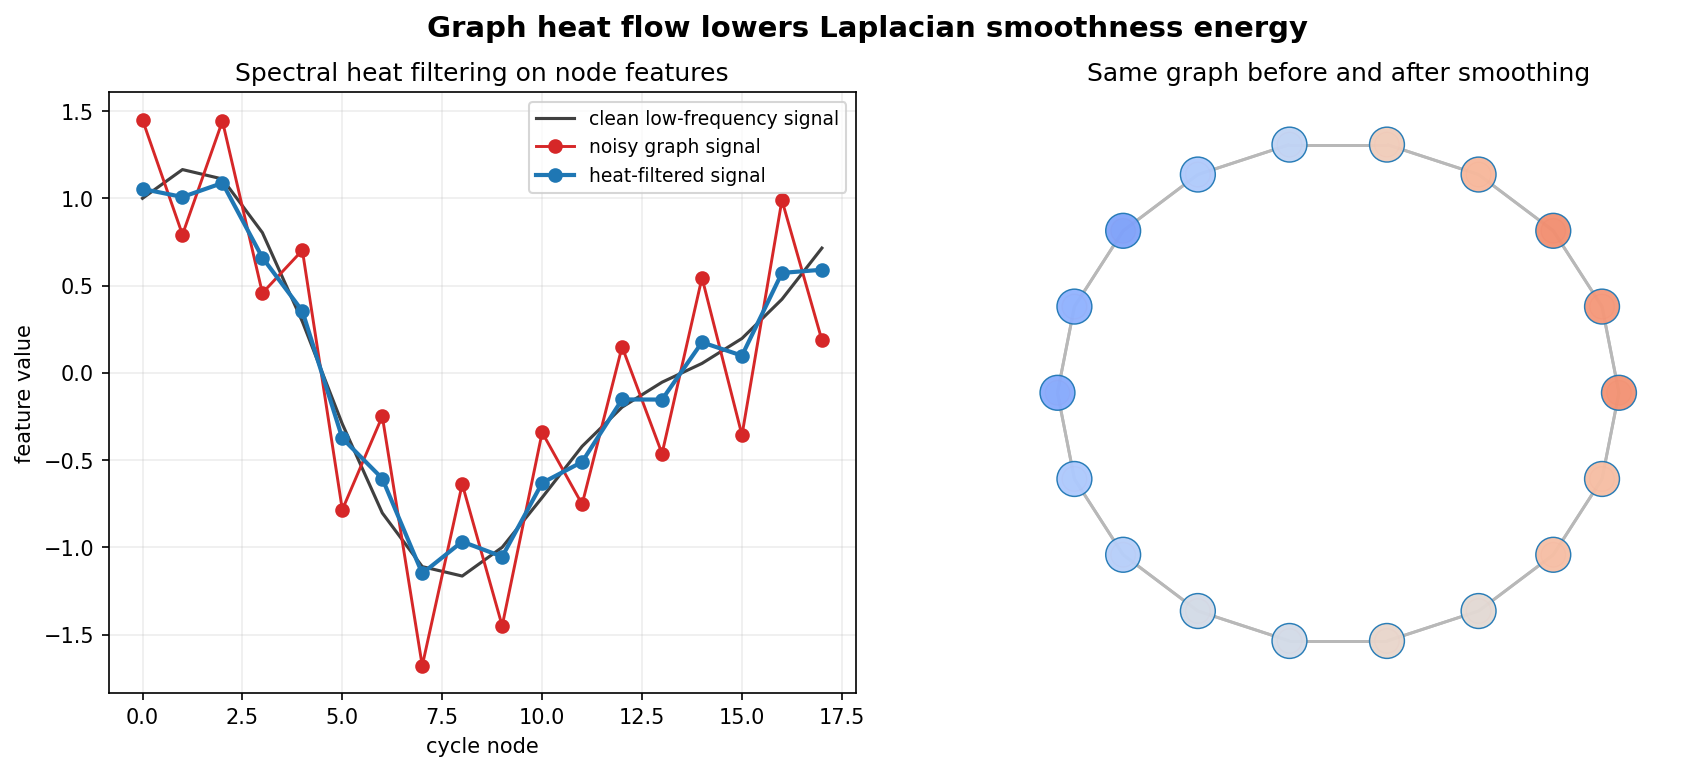

{'time': 0.38,
 'dirichlet_energy_noisy': 16.63916354843274,
 'dirichlet_energy_smoothed': 2.0806245829483054,
 'energy_drop': 14.558538965484436,
 'mean_noisy': 4.3175339846533866e-17,
 'mean_smoothed': 1.0485439677015367e-16,
 'mean_deviation': 6.167905692361981e-17}

In [10]:
node_index = np.arange(N_graph)
clean_graph_signal = np.cos(2 * np.pi * node_index / N_graph) + 0.35 * np.sin(4 * np.pi * node_index / N_graph)
noise_graph = 0.45 * ((-1) ** node_index) + 0.12 * np.sin(14 * np.pi * node_index / N_graph)
noisy_graph_signal = clean_graph_signal + noise_graph
t_graph = 0.38
heat_multiplier_graph = np.exp(-t_graph * evals_graph)
smoothed_graph_signal = evecs_graph @ (heat_multiplier_graph * (evecs_graph.T @ noisy_graph_signal))
energy_noisy = float(noisy_graph_signal @ L_graph @ noisy_graph_signal)
energy_smooth = float(smoothed_graph_signal @ L_graph @ smoothed_graph_signal)
mean_noisy = float(np.mean(noisy_graph_signal))
mean_smooth = float(np.mean(smoothed_graph_signal))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw={"width_ratios": [1.1, 1.0]})
axes[0].plot(node_index, clean_graph_signal, color="0.25", linewidth=1.5, label="clean low-frequency signal")
axes[0].plot(node_index, noisy_graph_signal, color="#d62728", marker="o", linewidth=1.4, label="noisy graph signal")
axes[0].plot(node_index, smoothed_graph_signal, color="#1f77b4", marker="o", linewidth=2.0, label="heat-filtered signal")
axes[0].set_title("Spectral heat filtering on node features")
axes[0].set_xlabel("cycle node")
axes[0].set_ylabel("feature value")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.22)

for label, values, color in [("noisy", noisy_graph_signal, "#d62728"), ("smoothed", smoothed_graph_signal, "#1f77b4")]:
    nx.draw_networkx_edges(G_cycle, pos_cycle, ax=axes[1], edge_color="0.72", width=1.4)
    nx.draw_networkx_nodes(
        G_cycle,
        pos_cycle,
        ax=axes[1],
        node_color=values,
        cmap="coolwarm",
        vmin=-2,
        vmax=2,
        node_size=140 if label == "noisy" else 280,
        edgecolors=color,
        linewidths=0.7,
        alpha=0.35 if label == "noisy" else 0.95,
    )
axes[1].set_title("Same graph before and after smoothing")
axes[1].axis("off")
fig.suptitle("Graph heat flow lowers Laplacian smoothness energy", fontsize=14, weight="bold")

path = register(save_matplotlib(fig, TOPIC, "graph-heat-filter-lab.png", root=ARTIFACT_LIBRARY_ROOT))
plt.close(fig)

checks["graph_heat_lab"] = {
    "time": t_graph,
    "dirichlet_energy_noisy": energy_noisy,
    "dirichlet_energy_smoothed": energy_smooth,
    "energy_drop": energy_noisy - energy_smooth,
    "mean_noisy": mean_noisy,
    "mean_smoothed": mean_smooth,
    "mean_deviation": abs(mean_noisy - mean_smooth),
}
display_book_artifact(path, width=950)
checks["graph_heat_lab"]


## Sanity checks and Takeaways

The checks below are intentionally redundant: they test algebraic identities, geometric residuals, and artifact integrity. The notebook is acceptable only if the figures exist, the PNG files are nonblank, and the spectral identities hold within numerical tolerance.

**Takeaways.**

- Eigenvectors and eigenfunctions are modes that make an operator act by scalar multiplication.
- Self-adjointness is the structural assumption that produces real spectra and orthogonal modes.
- Fourier analysis is spectral decomposition in an orthonormal function basis.
- SVD is the right replacement when the operator is not self-adjoint.
- Parseval says coefficient space preserves Hilbert-space geometry.
- Heat flow is a spectral filter whose damping rate is controlled by Laplacian eigenvalues.
- Graph Laplacian eigenvectors are the discrete bridge from classical Fourier modes to geometric deep learning on irregular domains.


In [11]:
invariant_path = register(save_json(checks, TOPIC, "spectral-invariants.json", root=ARTIFACT_LIBRARY_ROOT))

final_sanity = {
    "artifact_count": len(artifact_paths) + 1,
    "png_count": len(png_paths),
    "source_span_read": checks["source_span_read"],
    "thresholds": {
        "eigen_residual_lt": 1e-10,
        "self_adjoint_gram_residual_lt": 1e-10,
        "fourier_reconstruction_error_lt": 1e-12,
        "svd_reconstruction_residual_lt": 1e-12,
        "parseval_energy_gap_lt": 1e-10,
        "graph_cycle_formula_error_lt": 1e-10,
    },
    "key_results": {
        "eigen_max_residual": checks["eigen_directions"]["max_residual"],
        "self_adjoint_gram_residual": checks["self_adjoint_spectrum"]["gram_identity_residual"],
        "fourier_reconstruction_error": checks["fourier_gram"]["reconstruction_error"],
        "svd_reconstruction_residual": checks["svd"]["reconstruction_residual"],
        "parseval_energy_gap": checks["parseval"]["energy_gap"],
        "heat_energy_nonincreasing": checks["heat_flow"]["energy_nonincreasing"],
        "graph_cycle_formula_max_error": checks["graph_laplacian_bridge"]["cycle_formula_max_error"],
        "graph_heat_energy_drop": checks["graph_heat_lab"]["energy_drop"],
    },
}
final_sanity_path = register(save_json(final_sanity, TOPIC, "final-sanity.json", root=ARTIFACT_LIBRARY_ROOT))

records = assert_chapter_artifacts(artifact_paths)
image_records = [assert_nonblank_image(path) for path in png_paths]

assert checks["eigen_directions"]["max_residual"] < 1e-10
assert checks["self_adjoint_spectrum"]["max_imaginary_eigenvalue"] < 1e-12
assert checks["self_adjoint_spectrum"]["gram_identity_residual"] < 1e-10
assert checks["periodic_laplacian"]["max_mode_residual"] < 1e-9
assert checks["fourier_gram"]["gram_identity_residual"] < 1e-12
assert checks["fourier_gram"]["reconstruction_error"] < 1e-12
assert checks["svd"]["reconstruction_residual"] < 1e-12
assert checks["svd"]["direction_residual"] < 1e-12
assert checks["parseval"]["energy_gap"] < 1e-10
assert checks["parseval"]["reconstruction_error"] < 1e-12
assert checks["heat_flow"]["energy_nonincreasing"]
assert checks["heat_flow"]["mean_max_deviation"] < 1e-12
assert checks["graph_laplacian_bridge"]["cycle_formula_max_error"] < 1e-10
assert checks["graph_laplacian_bridge"]["constant_mode_residual"] < 1e-12
assert checks["graph_heat_lab"]["energy_drop"] > 0
assert checks["graph_heat_lab"]["mean_deviation"] < 1e-12

print(f"Validated {len(records)} artifacts, including {len(image_records)} nonblank PNG files.")
display_book_artifact(invariant_path)
display_book_artifact(final_sanity_path)


Validated 15 artifacts, including 9 nonblank PNG files.
